# Sparkov Credit-Card Fraud: EDA and Predictive Modelling

**Dataset role:** large synthetic behavioural benchmark.

Sparkov requires a different analysis from ULB because it contains meaningful
customer, merchant, time, category, demographic, and geographic fields.
This notebook:

- preserves the supplied later-period `fraudTest.csv` as the final holdout;
- uses a chronological validation window inside `fraudTrain.csv`;
- excludes direct identifiers and synthetic personal fields from prediction;
- engineers age, calendar, log-amount, and customer-to-merchant distance features;
- performs target-informed EDA on the training window only;
- uses validation data for model and threshold selection;
- reports final performance at the original test prevalence without resampling.



In [1]:
from __future__ import annotations

from pathlib import Path
import hashlib
import platform
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import imblearn
from IPython import get_ipython
from IPython.display import display

from imblearn.pipeline import Pipeline as ImbalancedPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler


SEED = 42
VALIDATION_FRACTION_BY_TIME = 0.20
PRIMARY_METRIC = "average_precision"
FBETA = 2.0

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.5f}")


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        required = candidate / "datasets" / "sparkov" / "fraudTrain.csv"
        if required.exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Run from thesis_code or one of its subdirectories.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_ROOT = PROJECT_ROOT / "datasets" / "sparkov"
TRAIN_PATH = DATA_ROOT / "fraudTrain.csv"
TEST_PATH = DATA_ROOT / "fraudTest.csv"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "sparkov"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))
from src.evaluation import (  # noqa: E402
    evaluation_rows,
    plot_confusion_summary,
    plot_diagnostics,
    plot_threshold_tradeoff,
    plot_validation_comparison,
    positive_class_scores,
    save_json,
    select_fbeta_threshold,
)
from src.evidence import build_alert_records, write_jsonl  # noqa: E402

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit_learn": sklearn.__version__,
    "imbalanced_learn": imblearn.__version__,
    "project_root": str(PROJECT_ROOT),
})



{'python': '3.13.5', 'pandas': '2.3.1', 'numpy': '2.3.2', 'scikit_learn': '1.6.1', 'imbalanced_learn': '0.13.0', 'project_root': '<REPOSITORY_ROOT>'}


## 1. Load only required fields and verify provenance

Direct names, street addresses, transaction identifiers, and raw card numbers are
used only for integrity checks where needed. They are never model predictors.



In [2]:
use_columns = [
    "trans_date_trans_time",
    "cc_num",
    "merchant",
    "category",
    "amt",
    "gender",
    "state",
    "city_pop",
    "lat",
    "long",
    "dob",
    "merch_lat",
    "merch_long",
    "is_fraud",
]

raw_train = pd.read_csv(
    TRAIN_PATH,
    usecols=use_columns,
    parse_dates=["trans_date_trans_time", "dob"],
    low_memory=False,
)
raw_test = pd.read_csv(
    TEST_PATH,
    usecols=use_columns,
    parse_dates=["trans_date_trans_time", "dob"],
    low_memory=False,
)

timestamp_order_violations = {}
for frame_name, frame in (("train", raw_train), ("test", raw_test)):
    assert set(frame["is_fraud"].unique()) == {0, 1}, f"Unexpected {frame_name} target."
    assert frame.isna().sum().sum() == 0, f"Missing values found in {frame_name}."
    timestamp_order_violations[frame_name] = int(
        (frame["trans_date_trans_time"].diff().dt.total_seconds() < 0).sum()
    )
    frame.sort_values("trans_date_trans_time", kind="stable", inplace=True)
    frame.reset_index(drop=True, inplace=True)
    assert frame["trans_date_trans_time"].is_monotonic_increasing

train_hash = hashlib.sha256(TRAIN_PATH.read_bytes()).hexdigest()
test_hash = hashlib.sha256(TEST_PATH.read_bytes()).hexdigest()

dataset_card = pd.DataFrame({
    "split": ["supplied_train", "supplied_test"],
    "rows": [len(raw_train), len(raw_test)],
    "fraud": [int(raw_train["is_fraud"].sum()), int(raw_test["is_fraud"].sum())],
    "fraud_rate": [raw_train["is_fraud"].mean(), raw_test["is_fraud"].mean()],
    "start": [raw_train["trans_date_trans_time"].min(), raw_test["trans_date_trans_time"].min()],
    "end": [raw_train["trans_date_trans_time"].max(), raw_test["trans_date_trans_time"].max()],
    "unique_cards": [raw_train["cc_num"].nunique(), raw_test["cc_num"].nunique()],
    "unique_merchants": [raw_train["merchant"].nunique(), raw_test["merchant"].nunique()],
    "source_timestamp_order_violations": [
        timestamp_order_violations["train"],
        timestamp_order_violations["test"],
    ],
})
display(dataset_card)

card_overlap = len(set(raw_train["cc_num"]) & set(raw_test["cc_num"]))
print("Cards appearing in both supplied periods:", card_overlap)



,split,rows,fraud,fraud_rate,start,end,unique_cards,unique_merchants,source_timestamp_order_violations
0,supplied_train,1296675,7506,0.00579,2019-01-01 00:00:18,2020-06-21 12:13:37,983,693,1
1,supplied_test,555719,2145,0.00386,2020-06-21 12:14:25,2020-12-31 23:59:34,924,693,0


Cards appearing in both supplied periods: 908


In [3]:
raw_train.sample(5, random_state=SEED)



,trans_date_trans_time,cc_num,merchant,category,amt,gender,state,lat,long,city_pop,dob,merch_lat,merch_long,is_fraud
1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51000,M,PA,40.61530,-79.45450,972,1997-10-23,40.42045,-78.86501,0
547406,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32000,F,OR,42.82500,-124.44090,217,1928-10-01,42.75886,-123.63634,0
110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53000,F,PA,39.96360,-79.78530,184,1945-11-04,40.47516,-78.89819,0
1285953,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33000,M,NY,42.95800,-77.30830,10717,1952-10-13,43.76751,-76.54238,0
271705,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29000,F,WY,41.64230,-104.19740,635,1973-07-13,41.04039,-104.09232,0


## 2. Deterministic feature engineering

All transformations use only values available at transaction time. No target encoding,
future aggregation, or test-fitted transformation is used.



In [4]:
def haversine_km(
    lat1: pd.Series,
    lon1: pd.Series,
    lat2: pd.Series,
    lon2: pd.Series,
) -> np.ndarray:
    """Vectorized great-circle distance in kilometres."""
    earth_radius_km = 6_371.0088
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)
    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad
    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(delta_lon / 2) ** 2
    )
    return 2 * earth_radius_km * np.arcsin(np.sqrt(a))


def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    timestamp = frame["trans_date_trans_time"]
    age_years = (timestamp - frame["dob"]).dt.days / 365.2425

    engineered = pd.DataFrame(index=frame.index)
    engineered["transaction_time"] = timestamp
    engineered["amt"] = frame["amt"].astype("float64")
    engineered["log_amt"] = np.log1p(frame["amt"])
    engineered["city_pop"] = frame["city_pop"].astype("float64")
    engineered["lat"] = frame["lat"].astype("float64")
    engineered["long"] = frame["long"].astype("float64")
    engineered["merch_lat"] = frame["merch_lat"].astype("float64")
    engineered["merch_long"] = frame["merch_long"].astype("float64")
    engineered["age"] = age_years.clip(lower=0, upper=110)
    engineered["distance_km"] = haversine_km(
        frame["lat"],
        frame["long"],
        frame["merch_lat"],
        frame["merch_long"],
    )
    engineered["hour"] = timestamp.dt.hour.astype("int8")
    engineered["day_of_week"] = timestamp.dt.dayofweek.astype("int8")
    engineered["month"] = timestamp.dt.month.astype("int8")
    engineered["is_weekend"] = (timestamp.dt.dayofweek >= 5).astype("int8")
    engineered["category"] = frame["category"].astype("category")
    engineered["gender"] = frame["gender"].astype("category")
    engineered["state"] = frame["state"].astype("category")
    engineered["is_fraud"] = frame["is_fraud"].astype("int8")
    return engineered


development = engineer_features(raw_train)
official_test = engineer_features(raw_test)
del raw_train



## 3. Lock chronological training, validation, and test windows



In [5]:
validation_cutoff = development["transaction_time"].quantile(
    1 - VALIDATION_FRACTION_BY_TIME,
    interpolation="nearest",
)
training_window = development[development["transaction_time"] < validation_cutoff].copy()
validation_window = development[development["transaction_time"] >= validation_cutoff].copy()

feature_columns = [
    column
    for column in development.columns
    if column not in {"transaction_time", "is_fraud"}
]
numeric_columns = [
    "amt",
    "log_amt",
    "city_pop",
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "age",
    "distance_km",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
]
categorical_columns = ["category", "gender", "state"]

X_train = training_window[feature_columns]
y_train = training_window["is_fraud"]
X_validation = validation_window[feature_columns]
y_validation = validation_window["is_fraud"]
X_test = official_test[feature_columns]
y_test = official_test["is_fraud"]

split_manifest = pd.DataFrame({
    "split": ["train", "validation", "official_test"],
    "rows": [len(X_train), len(X_validation), len(X_test)],
    "fraud": [int(y_train.sum()), int(y_validation.sum()), int(y_test.sum())],
    "fraud_rate": [y_train.mean(), y_validation.mean(), y_test.mean()],
    "start": [
        training_window["transaction_time"].min(),
        validation_window["transaction_time"].min(),
        official_test["transaction_time"].min(),
    ],
    "end": [
        training_window["transaction_time"].max(),
        validation_window["transaction_time"].max(),
        official_test["transaction_time"].max(),
    ],
})
display(split_manifest)

assert training_window["transaction_time"].max() < validation_window["transaction_time"].min()
assert validation_window["transaction_time"].max() < official_test["transaction_time"].min()

# Delete raw test fields so later EDA cannot accidentally use them.
del raw_test



,split,rows,fraud,fraud_rate,start,end
0,train,1037339,5968,0.00575,2019-01-01 00:00:18,2020-03-06 07:14:37
1,validation,259336,1538,0.00593,2020-03-06 07:15:17,2020-06-21 12:13:37
2,official_test,555719,2145,0.00386,2020-06-21 12:14:25,2020-12-31 23:59:34


## 4. Training-window EDA: imbalance, amount, and calendar patterns



,count,percent
is_fraud,,
Legitimate,1031371,99.42468
Fraud,5968,0.57532


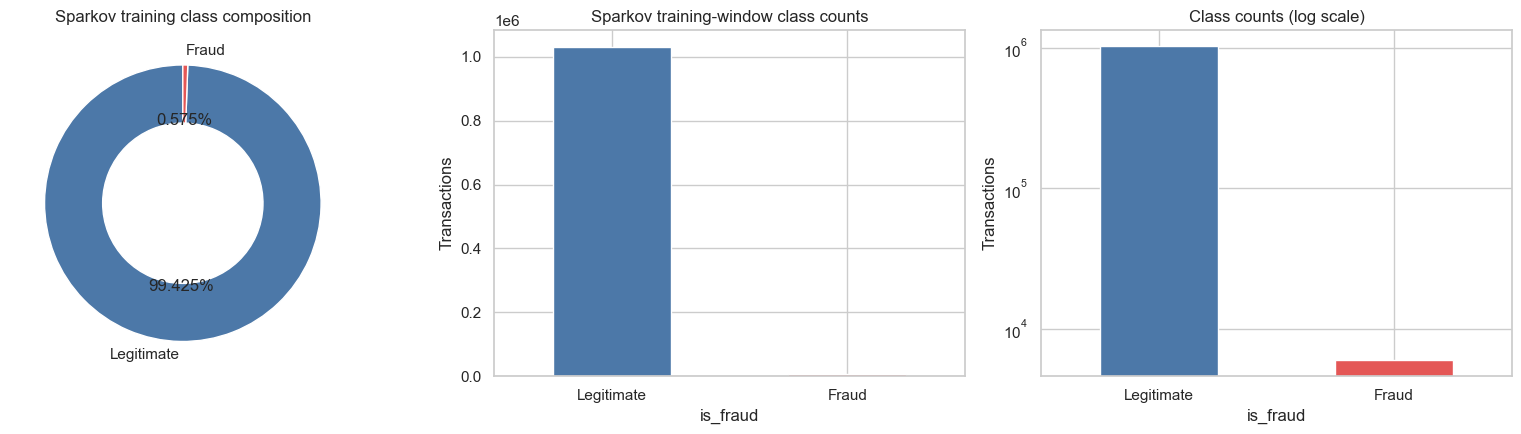

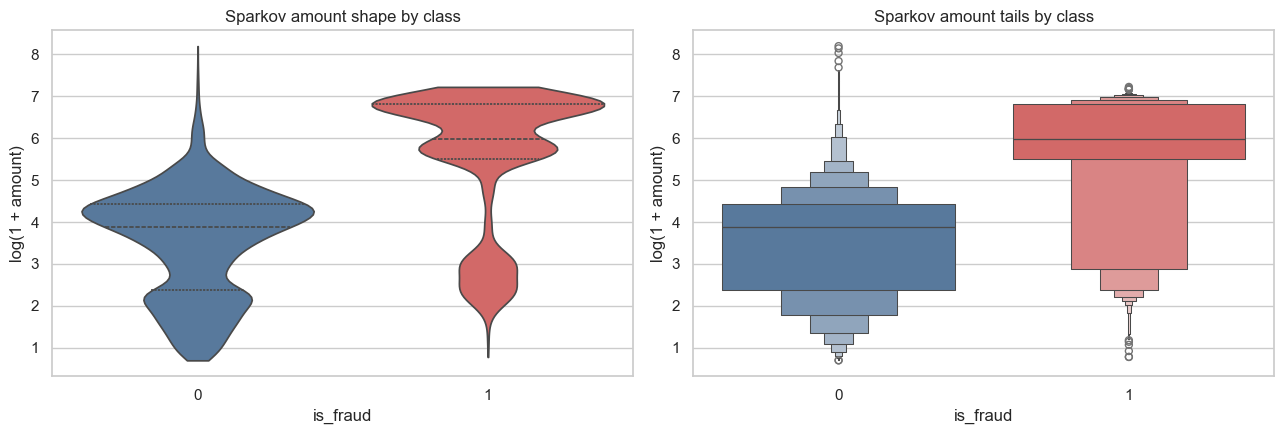

In [6]:
class_summary = (
    training_window["is_fraud"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Legitimate", 1: "Fraud"})
    .to_frame("count")
)
class_summary["percent"] = 100 * class_summary["count"] / len(training_window)
display(class_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].pie(
    class_summary["count"],
    labels=class_summary.index,
    colors=["#4C78A8", "#E45756"],
    autopct=lambda value: f"{value:.3f}%",
    startangle=90,
    wedgeprops={"width": 0.42, "edgecolor": "white"},
)
axes[0].set_title("Sparkov training class composition")
class_summary["count"].plot.bar(ax=axes[1], color=["#4C78A8", "#E45756"])
axes[1].set(title="Sparkov training-window class counts", ylabel="Transactions")
class_summary["count"].plot.bar(ax=axes[2], logy=True, color=["#4C78A8", "#E45756"])
axes[2].set(title="Class counts (log scale)", ylabel="Transactions")
for axis in axes[1:]:
    axis.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

amount_plot_frame = pd.concat([
    training_window.loc[training_window["is_fraud"] == 1],
    training_window.loc[training_window["is_fraud"] == 0].sample(
        n=min(10_000, int((training_window["is_fraud"] == 0).sum())),
        random_state=SEED,
    ),
])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.violinplot(
    data=amount_plot_frame,
    x="is_fraud",
    y="log_amt",
    hue="is_fraud",
    palette=["#4C78A8", "#E45756"],
    inner="quartile",
    cut=0,
    legend=False,
    ax=axes[0],
)
axes[0].set(title="Sparkov amount shape by class", ylabel="log(1 + amount)")
sns.boxenplot(
    data=amount_plot_frame,
    x="is_fraud",
    y="log_amt",
    hue="is_fraud",
    palette=["#4C78A8", "#E45756"],
    legend=False,
    ax=axes[1],
)
axes[1].set(title="Sparkov amount tails by class", ylabel="log(1 + amount)")
fig.tight_layout()
plt.show()



,count,mean,median,std,min,max
is_fraud,,,,,,
0,1031371,67.63372,47.22000,154.08934,1.00000,"28,948.90000"
1,5968,531.47157,397.84000,391.37841,1.18000,"1,371.81000"


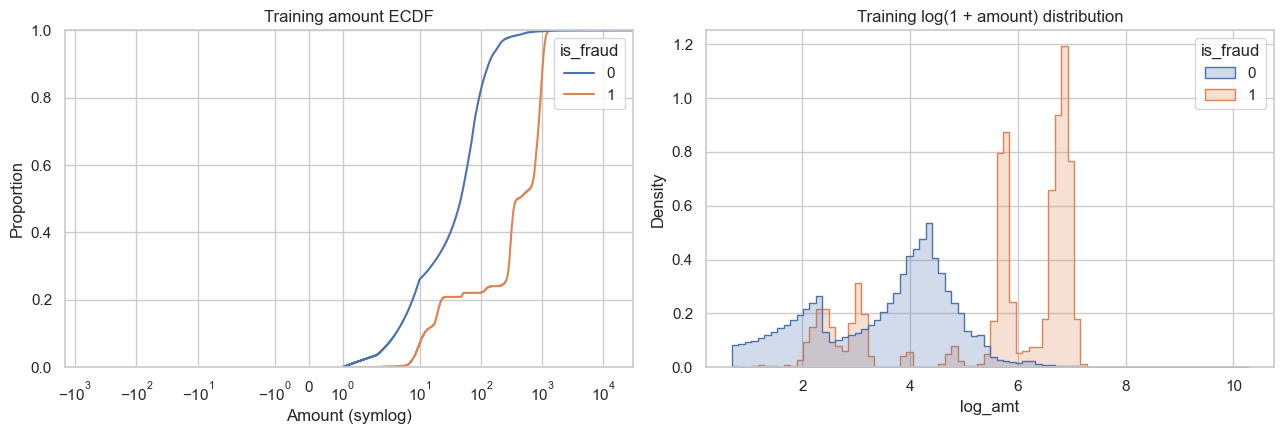

In [7]:
amount_summary = training_window.groupby("is_fraud")["amt"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)
display(amount_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.ecdfplot(data=training_window, x="amt", hue="is_fraud", ax=axes[0])
axes[0].set(xscale="symlog", title="Training amount ECDF", xlabel="Amount (symlog)")
sns.histplot(
    data=training_window,
    x="log_amt",
    hue="is_fraud",
    bins=80,
    stat="density",
    common_norm=False,
    element="step",
    ax=axes[1],
)
axes[1].set(title="Training log(1 + amount) distribution")
fig.tight_layout()
plt.show()



,transactions,fraud,fraud_rate
category,,,
shopping_net,78025,1370,0.01756
misc_net,50501,737,0.01459
grocery_pos,98808,1387,0.01404
shopping_pos,93330,661,0.00708
gas_transport,105247,493,0.00468
grocery_net,36337,110,0.00303
misc_pos,63813,193,0.00302
travel,32489,98,0.00302
entertainment,75208,184,0.00245


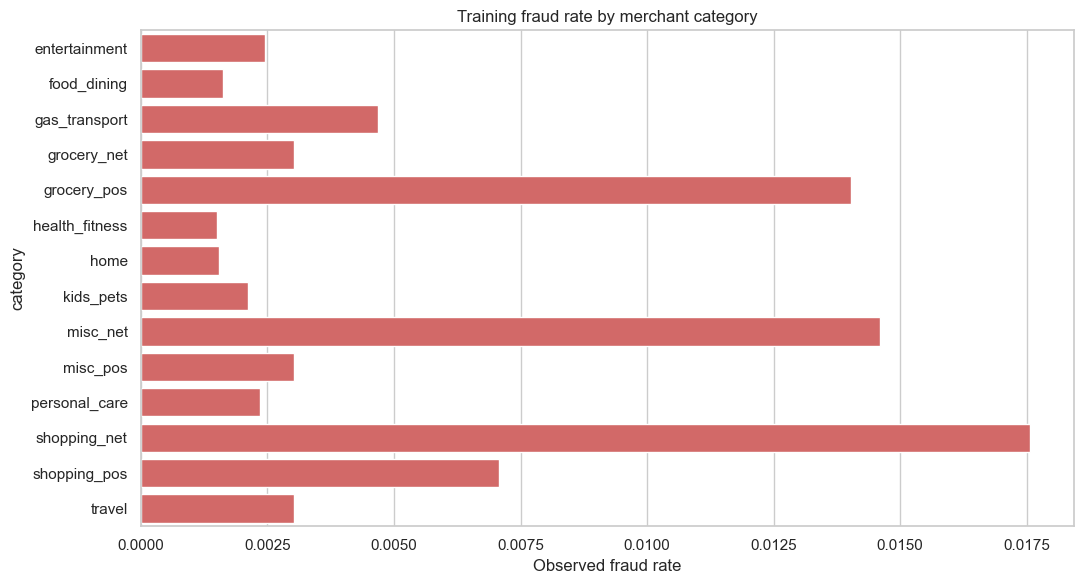

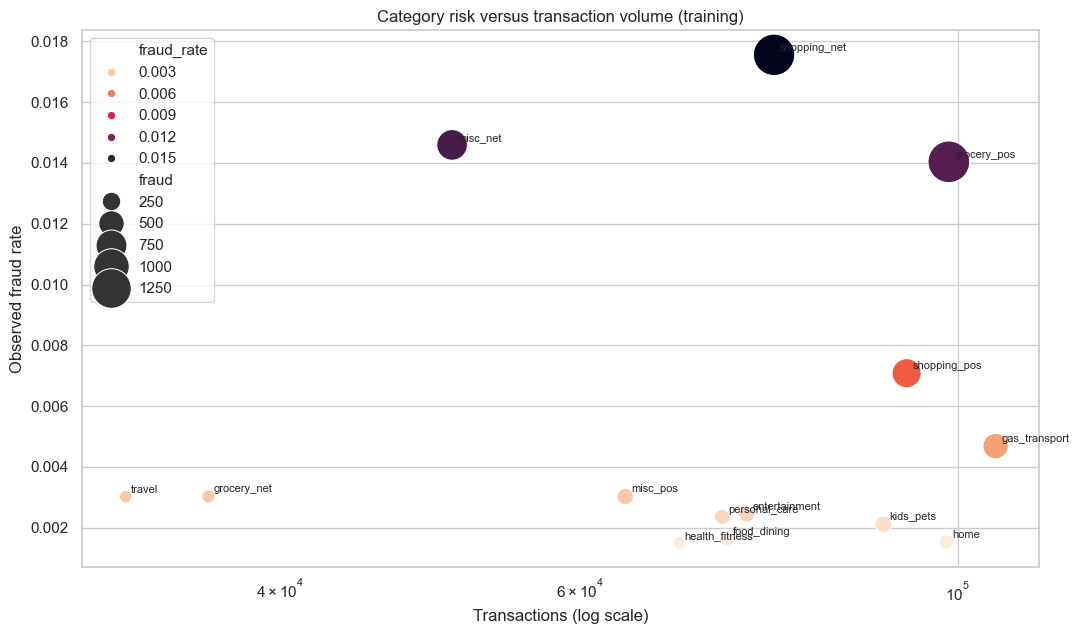

In [8]:
category_summary = (
    training_window
    .groupby("category", observed=True)["is_fraud"]
    .agg(transactions="count", fraud="sum", fraud_rate="mean")
    .sort_values("fraud_rate", ascending=False)
)
display(category_summary)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=category_summary.reset_index(),
    y="category",
    x="fraud_rate",
    color="#E45756",
    ax=ax,
)
ax.set(title="Training fraud rate by merchant category", xlabel="Observed fraud rate")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 6.5))
bubble = category_summary.reset_index()
sns.scatterplot(
    data=bubble,
    x="transactions",
    y="fraud_rate",
    size="fraud",
    hue="fraud_rate",
    sizes=(80, 900),
    palette="rocket_r",
    legend="brief",
    ax=ax,
)
for row in bubble.itertuples():
    ax.annotate(
        row.category,
        (row.transactions, row.fraud_rate),
        xytext=(4, 3),
        textcoords="offset points",
        fontsize=8,
    )
ax.set(
    xscale="log",
    title="Category risk versus transaction volume (training)",
    xlabel="Transactions (log scale)",
    ylabel="Observed fraud rate",
)
fig.tight_layout()
plt.show()



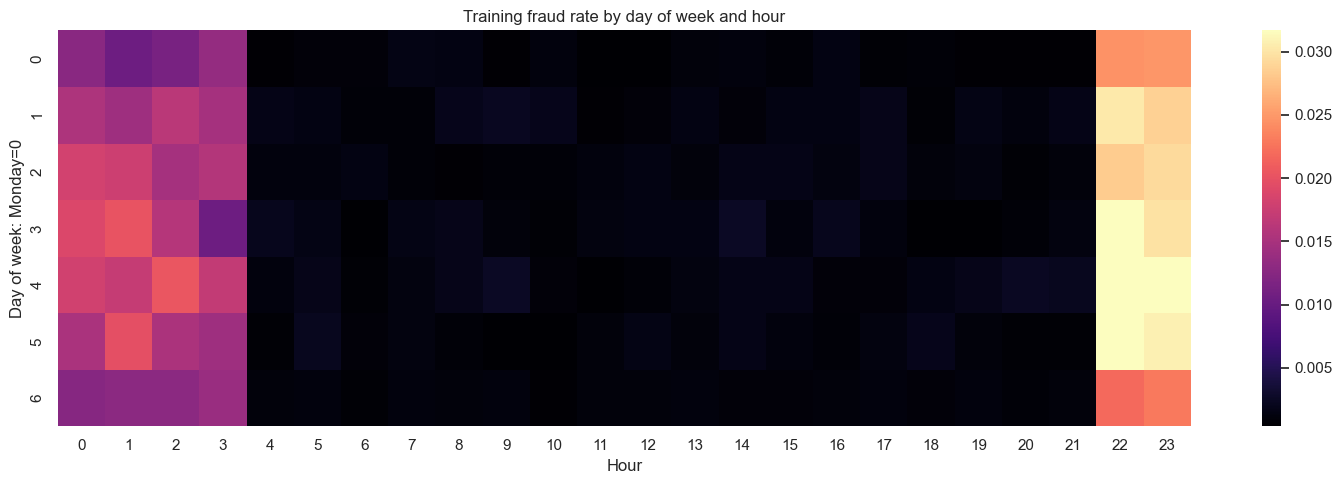

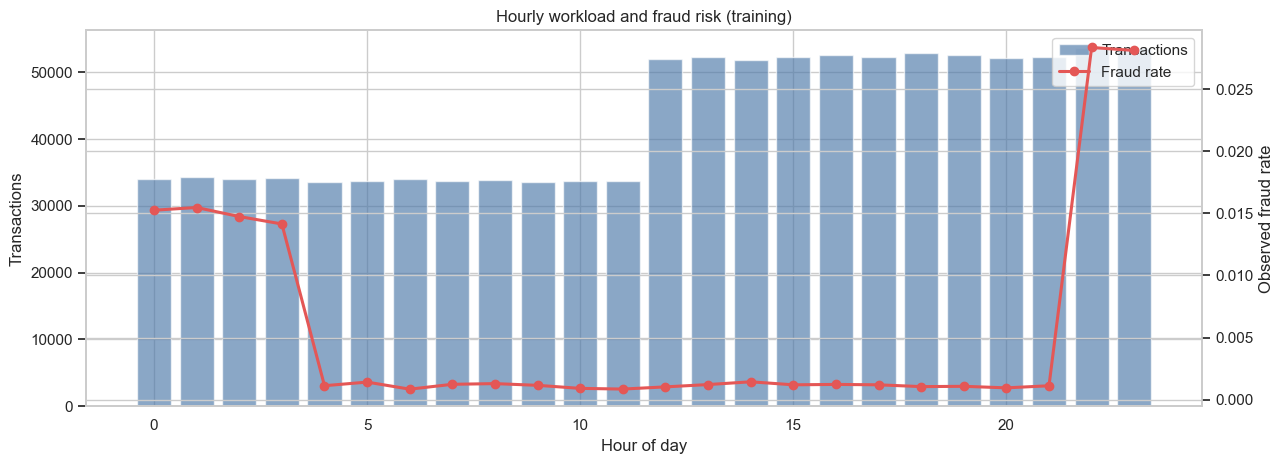

In [9]:
calendar_summary = (
    training_window
    .groupby(["day_of_week", "hour"], observed=True)["is_fraud"]
    .agg(transactions="count", fraud="sum", fraud_rate="mean")
    .reset_index()
)
fraud_rate_heatmap = calendar_summary.pivot(
    index="day_of_week",
    columns="hour",
    values="fraud_rate",
)
plt.figure(figsize=(15, 5))
sns.heatmap(fraud_rate_heatmap, cmap="magma", robust=True)
plt.title("Training fraud rate by day of week and hour")
plt.xlabel("Hour")
plt.ylabel("Day of week: Monday=0")
plt.tight_layout()
plt.show()

hourly_summary = (
    training_window.groupby("hour", observed=True)["is_fraud"]
    .agg(transactions="count", fraud="sum", fraud_rate="mean")
)
fig, ax_count = plt.subplots(figsize=(13, 4.8))
ax_rate = ax_count.twinx()
ax_count.bar(hourly_summary.index, hourly_summary["transactions"], color="#4C78A8", alpha=0.65, label="Transactions")
ax_rate.plot(hourly_summary.index, hourly_summary["fraud_rate"], color="#E45756", marker="o", linewidth=2.2, label="Fraud rate")
ax_count.set(title="Hourly workload and fraud risk (training)", xlabel="Hour of day", ylabel="Transactions")
ax_rate.set_ylabel("Observed fraud rate")
lines, labels = ax_count.get_legend_handles_labels()
lines2, labels2 = ax_rate.get_legend_handles_labels()
ax_count.legend(lines + lines2, labels + labels2, loc="upper right")
fig.tight_layout()
plt.show()



## 5. Training-window EDA: age, geography, and temporal drift



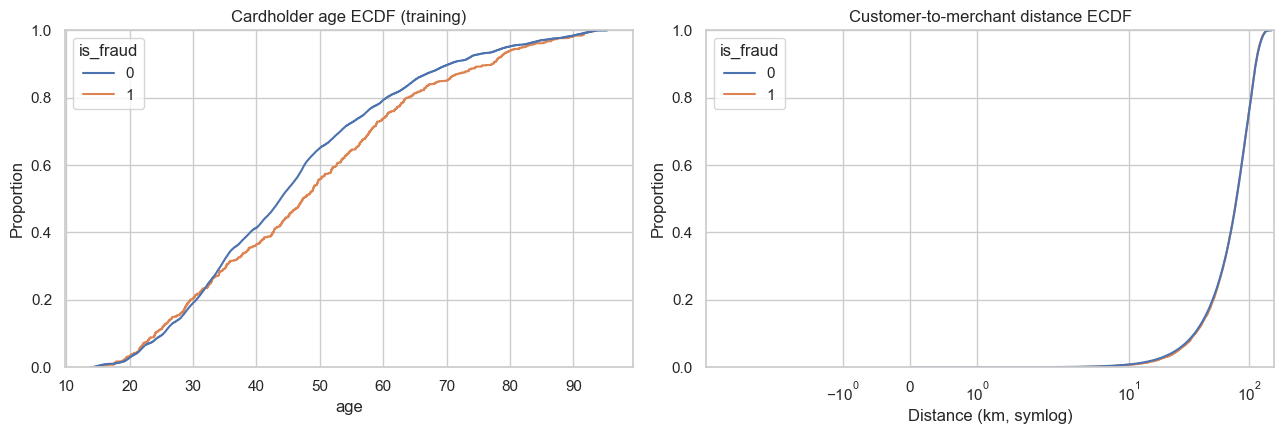

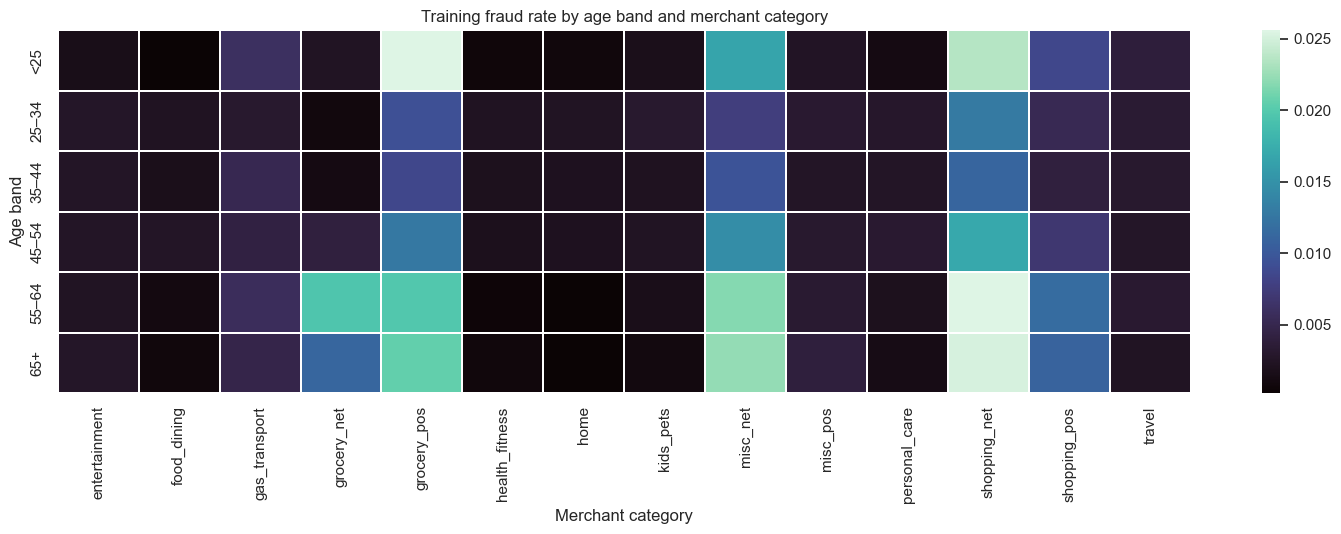

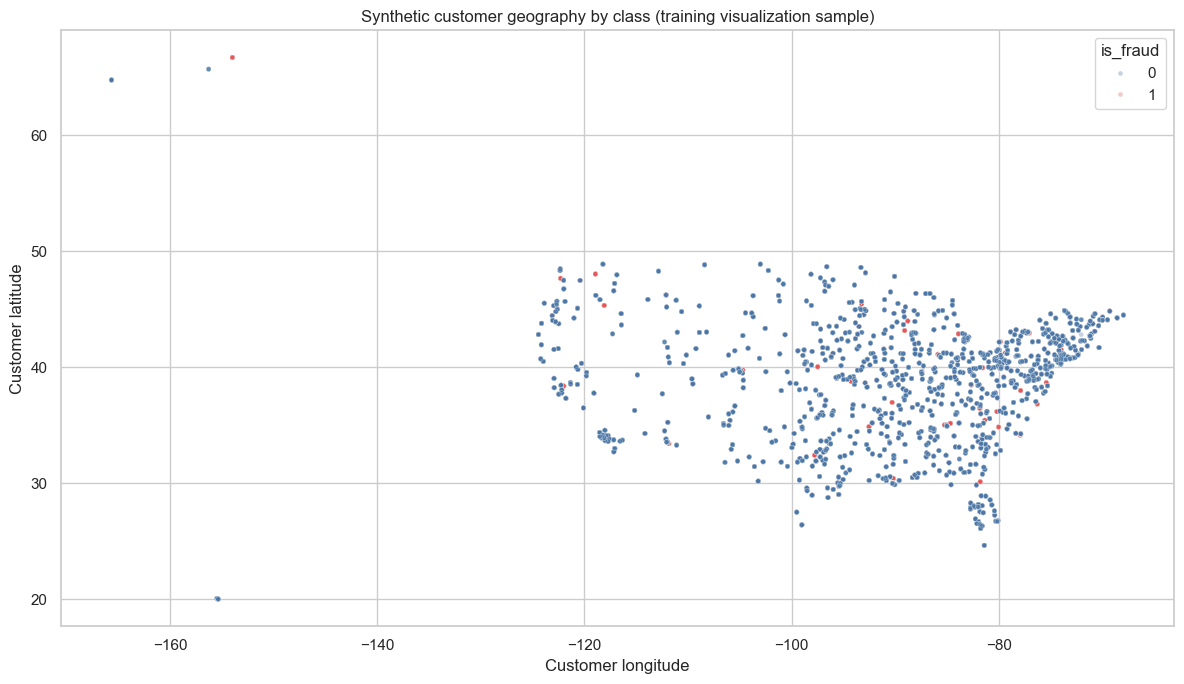

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.ecdfplot(data=training_window, x="age", hue="is_fraud", ax=axes[0])
axes[0].set(title="Cardholder age ECDF (training)")
sns.ecdfplot(data=training_window, x="distance_km", hue="is_fraud", ax=axes[1])
axes[1].set(xscale="symlog", title="Customer-to-merchant distance ECDF", xlabel="Distance (km, symlog)")
fig.tight_layout()
plt.show()

age_labels = ["<25", "25–34", "35–44", "45–54", "55–64", "65+"]
age_category = training_window.assign(
    age_band=pd.cut(
        training_window["age"],
        bins=[0, 25, 35, 45, 55, 65, 111],
        labels=age_labels,
        include_lowest=True,
        right=False,
    )
)
age_category_rates = age_category.pivot_table(
    index="age_band",
    columns="category",
    values="is_fraud",
    aggfunc="mean",
    observed=True,
)
plt.figure(figsize=(15, 5.5))
sns.heatmap(age_category_rates, cmap="mako", robust=True, linewidths=0.2)
plt.title("Training fraud rate by age band and merchant category")
plt.xlabel("Merchant category")
plt.ylabel("Age band")
plt.tight_layout()
plt.show()

geo_plot_frame = pd.concat([
    training_window.loc[training_window["is_fraud"] == 1],
    training_window.loc[training_window["is_fraud"] == 0].sample(
        n=min(30_000, int((training_window["is_fraud"] == 0).sum())),
        random_state=SEED,
    ),
])
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=geo_plot_frame,
    x="long",
    y="lat",
    hue="is_fraud",
    hue_order=[0, 1],
    palette={0: "#4C78A8", 1: "#E45756"},
    alpha=0.32,
    s=12,
)
plt.title("Synthetic customer geography by class (training visualization sample)")
plt.xlabel("Customer longitude")
plt.ylabel("Customer latitude")
plt.tight_layout()
plt.show()



,transactions,fraud,fraud_rate
month_period,,,
2019-01,52525,506,0.00963
2019-02,49866,517,0.01037
2019-03,70939,494,0.00696
2019-04,68078,376,0.00552
2019-05,72532,408,0.00563
2019-06,86064,354,0.00411
2019-07,86596,331,0.00382
2019-08,87359,382,0.00437
2019-09,70652,418,0.00592


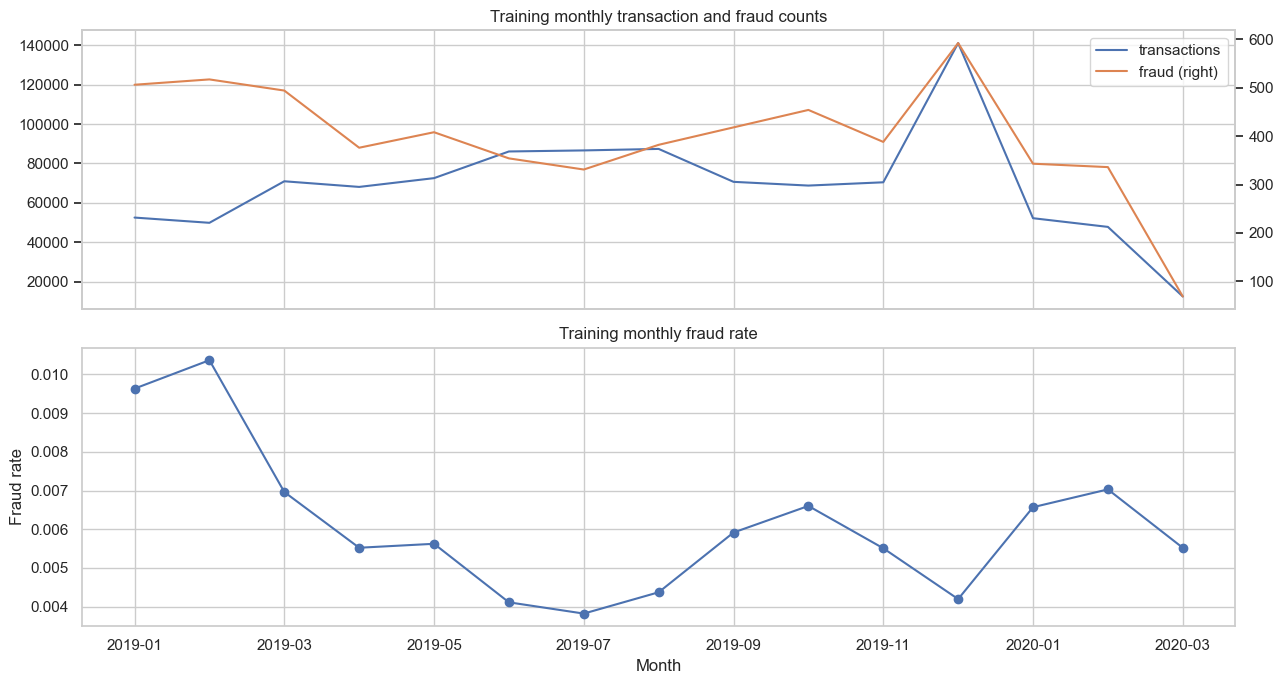

In [11]:
monthly = (
    training_window
    .assign(month_period=training_window["transaction_time"].dt.to_period("M").astype(str))
    .groupby("month_period")["is_fraud"]
    .agg(transactions="count", fraud="sum", fraud_rate="mean")
)
display(monthly)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
monthly[["transactions", "fraud"]].plot(ax=axes[0], secondary_y="fraud")
axes[0].set(title="Training monthly transaction and fraud counts")
monthly["fraud_rate"].plot(ax=axes[1], marker="o")
axes[1].set(title="Training monthly fraud rate", xlabel="Month", ylabel="Fraud rate")
fig.tight_layout()
plt.show()



## 6. Training-only class-balancing experiment

Sparkov contains categorical predictors. Ordinary SMOTE after ordinal or one-hot
encoding can create fractional pseudo-categories, so the safe ablation uses random
under-sampling only. It runs inside the model pipeline and never changes validation
or test prevalence.



,Original training,Training-only under-sampling
is_fraud,,
Legitimate,1031371,59680
Fraud,5968,5968


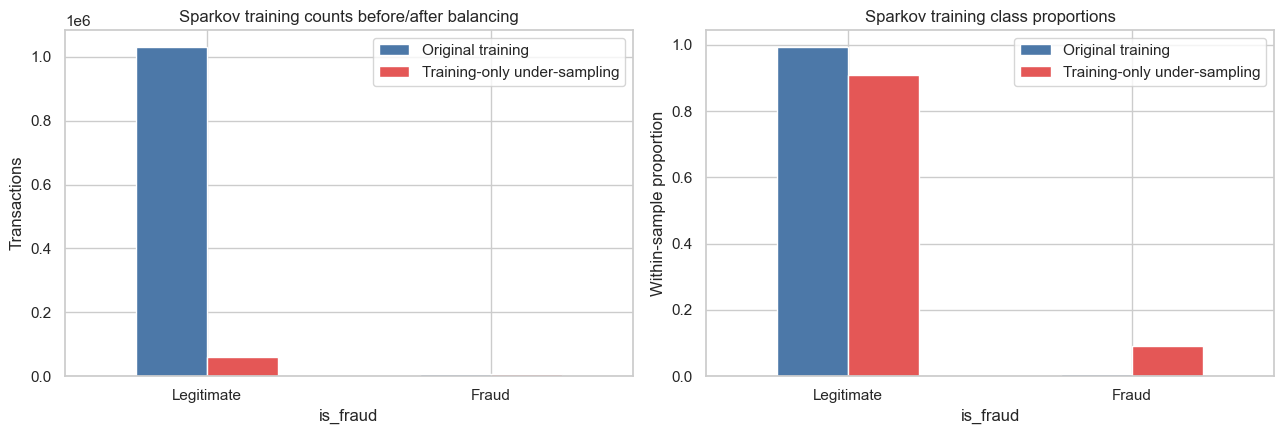

In [12]:
sparkov_under_sampler = RandomUnderSampler(sampling_strategy=0.10, random_state=SEED)
_, y_train_under_preview = sparkov_under_sampler.fit_resample(X_train, y_train)
balance_counts = pd.DataFrame({
    "Original training": y_train.value_counts().sort_index(),
    "Training-only under-sampling": pd.Series(y_train_under_preview).value_counts().sort_index(),
}).rename(index={0: "Legitimate", 1: "Fraud"})
display(balance_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
balance_counts.plot.bar(ax=axes[0], color=["#4C78A8", "#E45756"])
axes[0].set(title="Sparkov training counts before/after balancing", ylabel="Transactions")
(balance_counts / balance_counts.sum()).plot.bar(ax=axes[1], color=["#4C78A8", "#E45756"])
axes[1].set(title="Sparkov training class proportions", ylabel="Within-sample proportion")
for axis in axes:
    axis.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()



## 7. Dataset-specific preprocessing and candidate models

Linear models use sparse one-hot encoding. Tree models use ordinal encoding for
low-cardinality fields. High-cardinality card, person, transaction, merchant, street,
and job identifiers are intentionally excluded from these baselines.



In [13]:
numeric_pipeline_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
numeric_pipeline_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

one_hot_preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline_scaled, numeric_columns),
    ("categorical", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=100,
        sparse_output=True,
    ), categorical_columns),
])

ordinal_preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline_unscaled, numeric_columns),
    ("categorical", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
        encoded_missing_value=-1,
    ), categorical_columns),
])

categorical_mask = [False] * len(numeric_columns) + [True] * len(categorical_columns)

models = {
    "Dummy prior": Pipeline([
        ("preprocess", ordinal_preprocessor),
        ("model", DummyClassifier(strategy="prior")),
    ]),
    "Scalable logistic regression": Pipeline([
        ("preprocess", one_hot_preprocessor),
        ("model", SGDClassifier(
            loss="log_loss",
            penalty="elasticnet",
            l1_ratio=0.05,
            alpha=1e-5,
            class_weight="balanced",
            average=True,
            early_stopping=True,
            validation_fraction=0.10,
            n_iter_no_change=8,
            random_state=SEED,
        )),
    ]),
    "Scalable logistic + undersampling": ImbalancedPipeline([
        ("preprocess", one_hot_preprocessor),
        ("under", RandomUnderSampler(sampling_strategy=0.10, random_state=SEED)),
        ("model", SGDClassifier(
            loss="log_loss",
            penalty="elasticnet",
            l1_ratio=0.05,
            alpha=1e-5,
            average=True,
            early_stopping=True,
            validation_fraction=0.10,
            n_iter_no_change=8,
            random_state=SEED,
        )),
    ]),
    "Random forest": Pipeline([
        ("preprocess", ordinal_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=24,
            min_samples_leaf=5,
            max_samples=0.50,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=SEED,
        )),
    ]),
    "Histogram gradient boosting": Pipeline([
        ("preprocess", ordinal_preprocessor),
        ("model", HistGradientBoostingClassifier(
            categorical_features=categorical_mask,
            class_weight="balanced",
            learning_rate=0.08,
            max_iter=250,
            max_leaf_nodes=31,
            min_samples_leaf=40,
            l2_regularization=1.0,
            random_state=SEED,
        )),
    ]),
}



## 8. Validation-only model and threshold selection



Training Dummy prior...


Training Scalable logistic regression...


Training Scalable logistic + undersampling...


Training Random forest...


Training Histogram gradient boosting...


,dataset,model,split,threshold_rule,n,fraud_n,fraud_rate,threshold,average_precision,roc_auc,precision,recall,specificity,f1,f2,balanced_accuracy,mcc,brier,tn,fp,fn,tp
6,Sparkov,Random forest,validation,default_0.5,259336,1538,0.00593,0.50000,0.89833,0.99601,0.85666,0.82380,0.99918,0.83991,0.83017,0.91149,0.83913,0.00170,257586,212,271,1267
7,Sparkov,Random forest,validation,validation_tuned,259336,1538,0.00593,0.41071,0.89833,0.99601,0.78691,0.85241,0.99862,0.81835,0.83845,0.92551,0.81789,0.00170,257443,355,227,1311
8,Sparkov,Histogram gradient boosting,validation,default_0.5,259336,1538,0.00593,0.50000,0.89624,0.99780,0.36445,0.94928,0.99012,0.52670,0.71865,0.96970,0.58488,0.00756,255252,2546,78,1460
9,Sparkov,Histogram gradient boosting,validation,validation_tuned,259336,1538,0.00593,0.87438,0.89624,0.99780,0.68705,0.87646,0.99762,0.77029,0.83066,0.93704,0.77453,0.00756,257184,614,190,1348
2,Sparkov,Scalable logistic regression,validation,default_0.5,259336,1538,0.00593,0.50000,0.19779,0.92620,0.06066,0.81404,0.92480,0.11291,0.23367,0.86942,0.20961,0.06868,238412,19386,286,1252
3,Sparkov,Scalable logistic regression,validation,validation_tuned,259336,1538,0.00593,1.00000,0.19779,0.92620,0.24227,0.72822,0.98641,0.36358,0.51972,0.85732,0.41468,0.06868,254295,3503,418,1120
4,Sparkov,Scalable logistic + undersampling,validation,default_0.5,259336,1538,0.00593,0.50000,0.19087,0.87919,0.28917,0.53641,0.99213,0.37577,0.45808,0.76427,0.38906,0.00962,255770,2028,713,825
5,Sparkov,Scalable logistic + undersampling,validation,validation_tuned,259336,1538,0.00593,0.39005,0.19087,0.87919,0.26698,0.55982,0.99083,0.36154,0.45910,0.77532,0.38152,0.00962,255434,2364,677,861
0,Sparkov,Dummy prior,validation,default_0.5,259336,1538,0.00593,0.50000,0.00593,0.50000,0.00000,0.00000,1.00000,0.00000,0.00000,0.50000,0.00000,0.00590,257798,0,1538,0
1,Sparkov,Dummy prior,validation,validation_tuned,259336,1538,0.00593,0.00575,0.00593,0.50000,0.00593,1.00000,0.00000,0.01179,0.02897,0.50000,0.00000,0.00590,0,257798,0,1538


Selected model: Random forest
Validation-selected F2 threshold: 0.41071273660926644


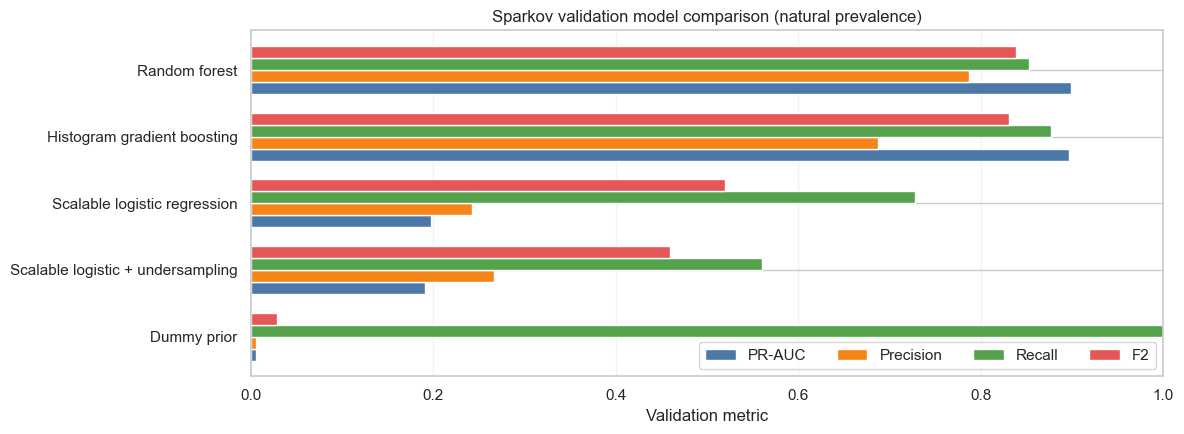

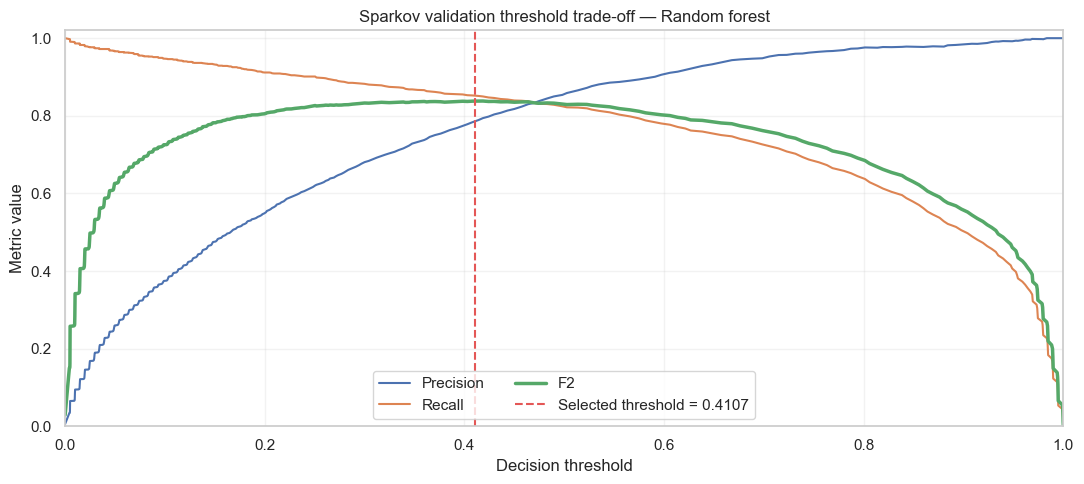

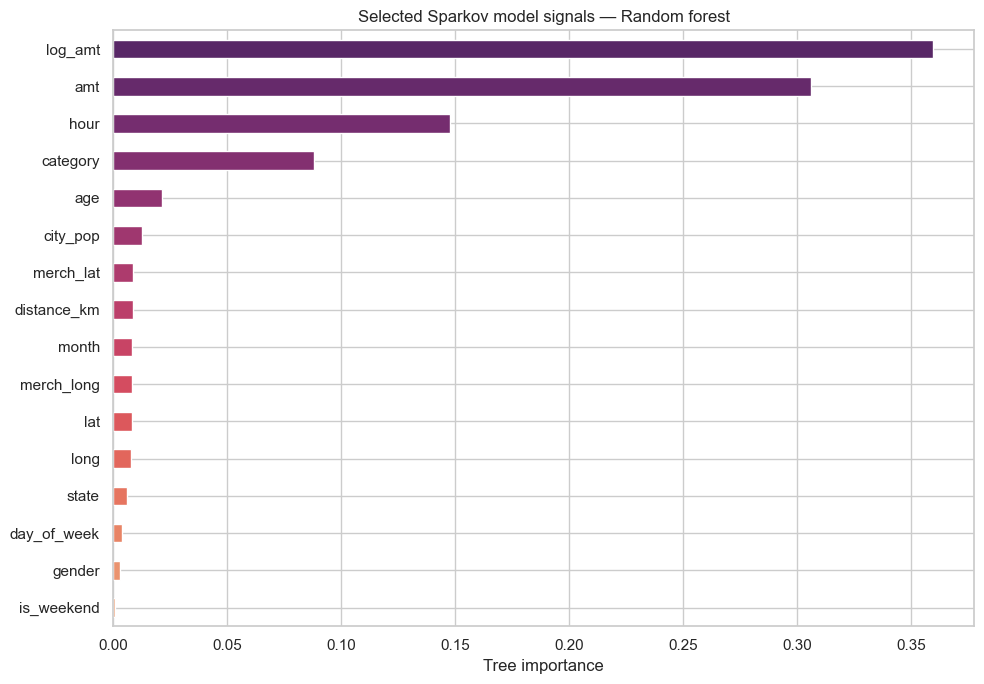

In [14]:
trained_models = {}
validation_rows = []
thresholds = {}
validation_scores = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    trained_models[model_name] = model

    validation_score = positive_class_scores(model, X_validation)
    validation_scores[model_name] = validation_score
    threshold_result = select_fbeta_threshold(
        y_validation,
        validation_score,
        beta=FBETA,
    )
    thresholds[model_name] = threshold_result["threshold"]
    validation_rows.append(
        evaluation_rows(
            dataset="Sparkov",
            model_name=model_name,
            split="validation",
            y_true=y_validation,
            y_score=validation_score,
            tuned_threshold=threshold_result["threshold"],
            beta=FBETA,
        )
    )

validation_results = pd.concat(validation_rows, ignore_index=True)
display(validation_results.sort_values([PRIMARY_METRIC, "model"], ascending=[False, True]))

selection_table = validation_results[
    validation_results["threshold_rule"] == "validation_tuned"
].sort_values(PRIMARY_METRIC, ascending=False)
best_model_name = selection_table.iloc[0]["model"]
best_model = trained_models[best_model_name]
best_threshold = thresholds[best_model_name]

print("Selected model:", best_model_name)
print("Validation-selected F2 threshold:", best_threshold)

plot_validation_comparison(
    validation_results,
    beta=FBETA,
    title="Sparkov validation model comparison (natural prevalence)",
)
plt.show()

plot_threshold_tradeoff(
    y_validation,
    validation_scores[best_model_name],
    selected_threshold=best_threshold,
    beta=FBETA,
    title=f"Sparkov validation threshold trade-off — {best_model_name}",
)
plt.show()

selected_model_step = best_model.named_steps["model"]
if hasattr(selected_model_step, "feature_importances_"):
    importance_values = selected_model_step.feature_importances_
    importance_label = "Tree importance"
elif hasattr(selected_model_step, "coef_"):
    importance_values = np.abs(selected_model_step.coef_[0])
    importance_label = "Absolute model coefficient"
else:
    importance_values = None

if importance_values is not None:
    transformed_names = pd.Index(
        best_model.named_steps["preprocess"].get_feature_names_out()
    ).str.replace(r"^(numeric|categorical)__", "", regex=True)
    selected_importance = pd.Series(importance_values, index=transformed_names).nlargest(20)
    fig, ax = plt.subplots(figsize=(10, 7))
    selected_importance.sort_values().plot.barh(
        color=sns.color_palette("flare", len(selected_importance)),
        ax=ax,
    )
    ax.set(
        title=f"Selected Sparkov model signals — {best_model_name}",
        xlabel=importance_label,
    )
    fig.tight_layout()
    plt.show()



## 9. One-time evaluation on the supplied later-period test file



,dataset,model,split,threshold_rule,n,fraud_n,fraud_rate,threshold,average_precision,roc_auc,precision,recall,specificity,f1,f2,balanced_accuracy,mcc,brier,tn,fp,fn,tp
0,Sparkov,Random forest,official_test,default_0.5,555719,2145,0.00386,0.50000,0.84845,0.99261,0.81027,0.77249,0.99930,0.79093,0.77976,0.88590,0.79037,0.00142,553186,388,488,1657
1,Sparkov,Random forest,official_test,validation_tuned,555719,2145,0.00386,0.41071,0.84845,0.99261,0.72567,0.80653,0.99882,0.76397,0.78895,0.90267,0.76408,0.00142,552920,654,415,1730


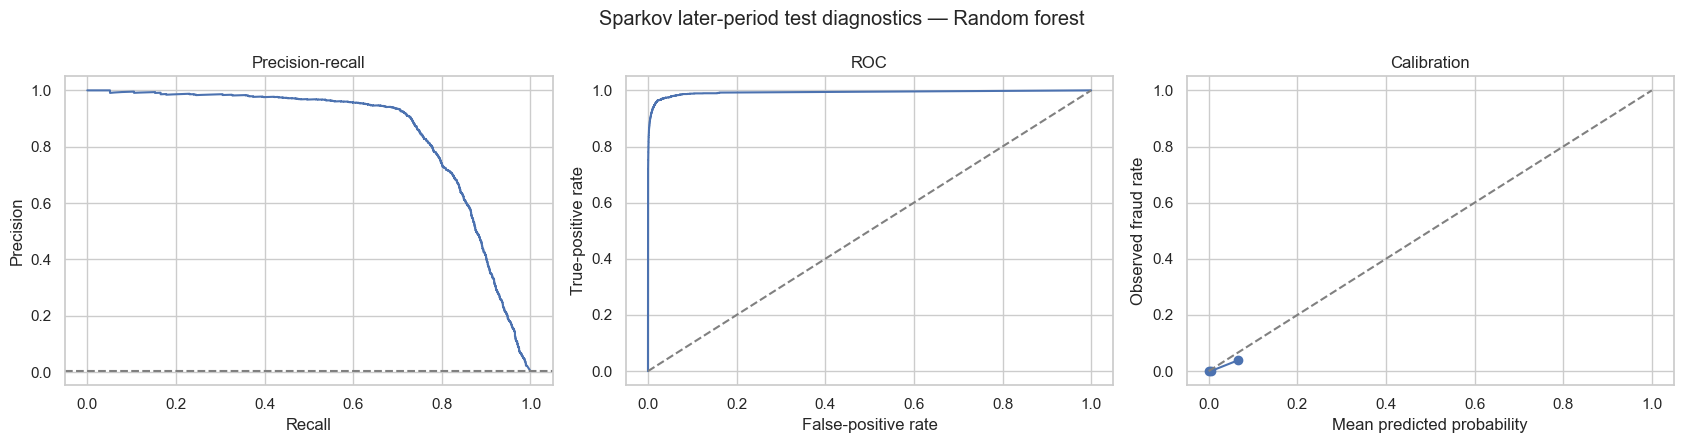

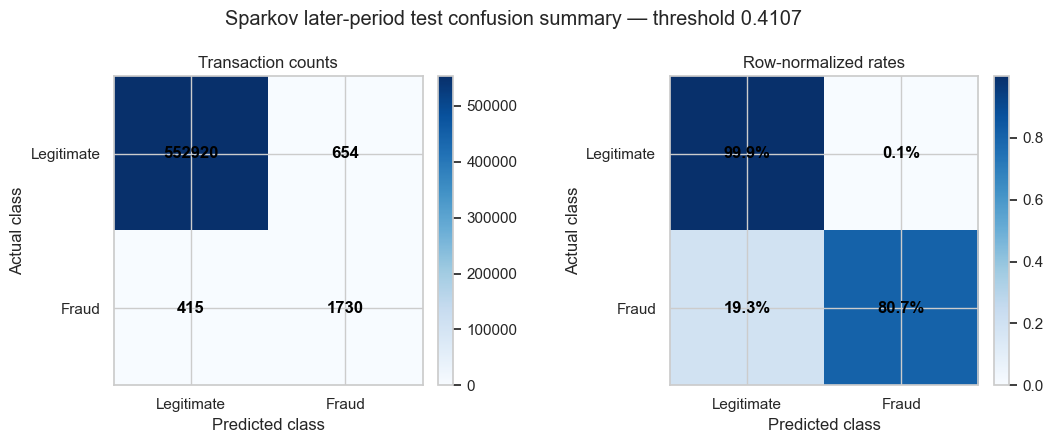

In [15]:
test_score = positive_class_scores(best_model, X_test)
test_results = evaluation_rows(
    dataset="Sparkov",
    model_name=best_model_name,
    split="official_test",
    y_true=y_test,
    y_score=test_score,
    tuned_threshold=best_threshold,
    beta=FBETA,
)
display(test_results)

plot_diagnostics(
    y_test,
    test_score,
    title=f"Sparkov later-period test diagnostics — {best_model_name}",
)
plt.show()

plot_confusion_summary(
    y_test,
    test_score,
    threshold=best_threshold,
    title=f"Sparkov later-period test confusion summary — threshold {best_threshold:.4f}",
)
plt.show()



## 10. Save reproducible artifacts



In [16]:
joblib.dump(best_model, ARTIFACT_DIR / "selected_pipeline.joblib")
validation_results.to_csv(ARTIFACT_DIR / "validation_metrics.csv", index=False)
test_results.to_csv(ARTIFACT_DIR / "test_metrics.csv", index=False)
pd.DataFrame({
    "transaction_time": official_test["transaction_time"].to_numpy(),
    "actual": y_test.to_numpy(),
    "fraud_probability": test_score,
}).to_csv(ARTIFACT_DIR / "test_predictions.csv", index=False)

llm_alert_records = build_alert_records(
    dataset_id="Sparkov",
    features=X_test,
    y_true=y_test,
    scores=test_score,
    threshold=best_threshold,
    model_name=best_model_name,
    record_ids=[f"sparkov-test-{index}" for index in X_test.index],
    event_times=official_test["transaction_time"].tolist(),
)
write_jsonl(llm_alert_records, ARTIFACT_DIR / "llm_alert_evidence.jsonl")

save_json({
    "dataset": "Sparkov",
    "data_nature": "synthetic credit-card transactions",
    "train_sha256": train_hash,
    "test_sha256": test_hash,
    "seed": SEED,
    "validation_cutoff": str(validation_cutoff),
    "source_timestamp_order_violations": timestamp_order_violations,
    "selected_model": best_model_name,
    "primary_metric": PRIMARY_METRIC,
    "threshold_selection": f"maximum validation F{FBETA:g}",
    "selected_threshold": best_threshold,
    "excluded_direct_identifiers": [
        "cc_num",
        "first",
        "last",
        "street",
        "trans_num",
        "Unnamed: 0",
    ],
    "split_manifest": split_manifest.astype({"start": str, "end": str}).to_dict(orient="records"),
    "versions": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
        "imbalanced_learn": imblearn.__version__,
    },
}, ARTIFACT_DIR / "run_manifest.json")

print("Artifacts saved to", ARTIFACT_DIR)
print("LLM-ready alert records:", len(llm_alert_records))



Artifacts saved to artifacts/sparkov
LLM-ready alert records: 2384


## 11. Interpretation boundaries

- Sparkov is synthetic; it cannot establish deployment performance on real bank data.
- The later-period holdout is more realistic than a random split, but it comes from the same generator.
- Direct identifiers are excluded, so these baselines do not model customer-level transaction sequences.
- Adding rolling card/merchant behavioural aggregates requires strictly past-only computation.
- ULB and Sparkov metrics may be compared at the study level, but their rows and features must not be merged.
